# Machine Learning Fundamentals: Model Selection for Classification

In this notebook, we will explore **model selection** for classification tasks using Python's **scikit-learn** library.
Model selection is the process of choosing the best model (and its hyperparameters) for a given task. This is a crucial step in any machine learning workflow.

## Learning objectives

By the end of this notebook, you will be able to:
- Understand the difference between model parameters and hyperparameters
- Use **cross-validation** to estimate model performance without peeking at the test set
- Tune hyperparameters systematically using **GridSearchCV** and **RandomizedSearchCV**
- Perform a final, unbiased evaluation on a held-out test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
 )

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("Imports ready.")

Imports ready.


## 1. Load and explore the dataset

We will use the **eeg-eye-state** dataset from OpenML, which contains measurements from a short electroencephalography (EEG) recording. EEG signals capture the electrical activity of the brain and are commonly used in neuroscience research and clinical applications. In this case, the signals were recorded with an Emotiv Neuroheadset with 14 channels, while the subject was either keeping their eyes open or closed.

<p align="center">
<img src="../images/scalp-eeg.png" alt="PCA example" width="600"/>
</p>

The dataset contains 14980 samples, each with 14 features corresponding to the EEG channels, and a binary target variable indicating whether the subject's eyes were open (0) or closed (1). The feature values represent the voltage recorded at each channel, which can be used to infer the brain's activity patterns.

The goal is to predict whether the subject's eyes were open or closed based on the EEG signals (i.e. based on the recordings of the brain activity). It offers a gentle introduction to working with time‑series like biological signals without the complexity of raw sensor data. Classifying eye state from EEG activity is also a common example in brain‑computer interface research, where the aim is to decode mental states from brain signals.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How many samples and how many features do we have?
- Are the classes balanced? Why does this matter?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The dataset contains 14980 samples and 14 features.
- The classes are relatively balanced (6700 open vs 8200 closed). This is important when we interpret performance metrics, as imbalanced classes can lead to misleading accuracy scores.
</div>


In [2]:
# Fetch dataset from OpenML (requires internet the first time; afterwards it may be cached)
eeg_data = fetch_openml(name="eeg-eye-state", version=1, as_frame=True)

X = eeg_data.data.copy().to_numpy()
y = eeg_data.target.copy().to_numpy()

feature_names = eeg_data.feature_names
target_labels = ['closed' if label == '1' else 'open' for label in y]
target_names = ['open', 'closed']

print(f"X shape: {X.shape} | y shape: {y.shape}")
print("Features:", feature_names)
print("Classes:", set(target_labels))

# Combine into one DataFrame for plotting
df = eeg_data.frame.copy()
df['Class'] = target_labels
df.head()

X shape: (14980, 14) | y shape: (14980,)
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14']
Classes: {'open', 'closed'}


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,Class
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,closed
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,closed
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,closed
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,closed
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,closed


In [3]:
df['Class'].value_counts()

Class
closed    8257
open      6723
Name: count, dtype: int64

***

You know the drill by now: we will start by loading the dataset and doing some basic exploratory data analysis (EDA) to understand the structure of the data and the relationships between the features and the target variable.

Write your own code to create a pair plot of the features (colored by the target variable) and to compute the correlation matrix of the features.

> Hint: look at the previous notebooks for examples of how to do this. To avoid long plotting times, you can use a random subsample of the data (e.g. df.sample(1000)) for the pair plot. You might also choose a subset of the features to plot (e.g. the first 5 features) if you want to see more details.
>
> 

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- What do you observe in the pair plot? Are there any clear patterns or clusters?
- Are there any features that are highly correlated with each other? What does this mean for our model?
- Do you think linear or non-linear models will perform better on this dataset? Why?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The classes show a lot of overlap in the feature space, which suggests that the classification task might be challenging. The features have log-normal distributions, which might suggest that a log transformation could be beneficial for some models.
- Some of the features are correlated with each other, which could lead to multicollinearity issues for linear models.
- Non-linear models might perform better on this dataset, as the relationships between the features and the target variable might not be strictly linear. However, this is something we will need to test empirically by comparing different models.
</div>


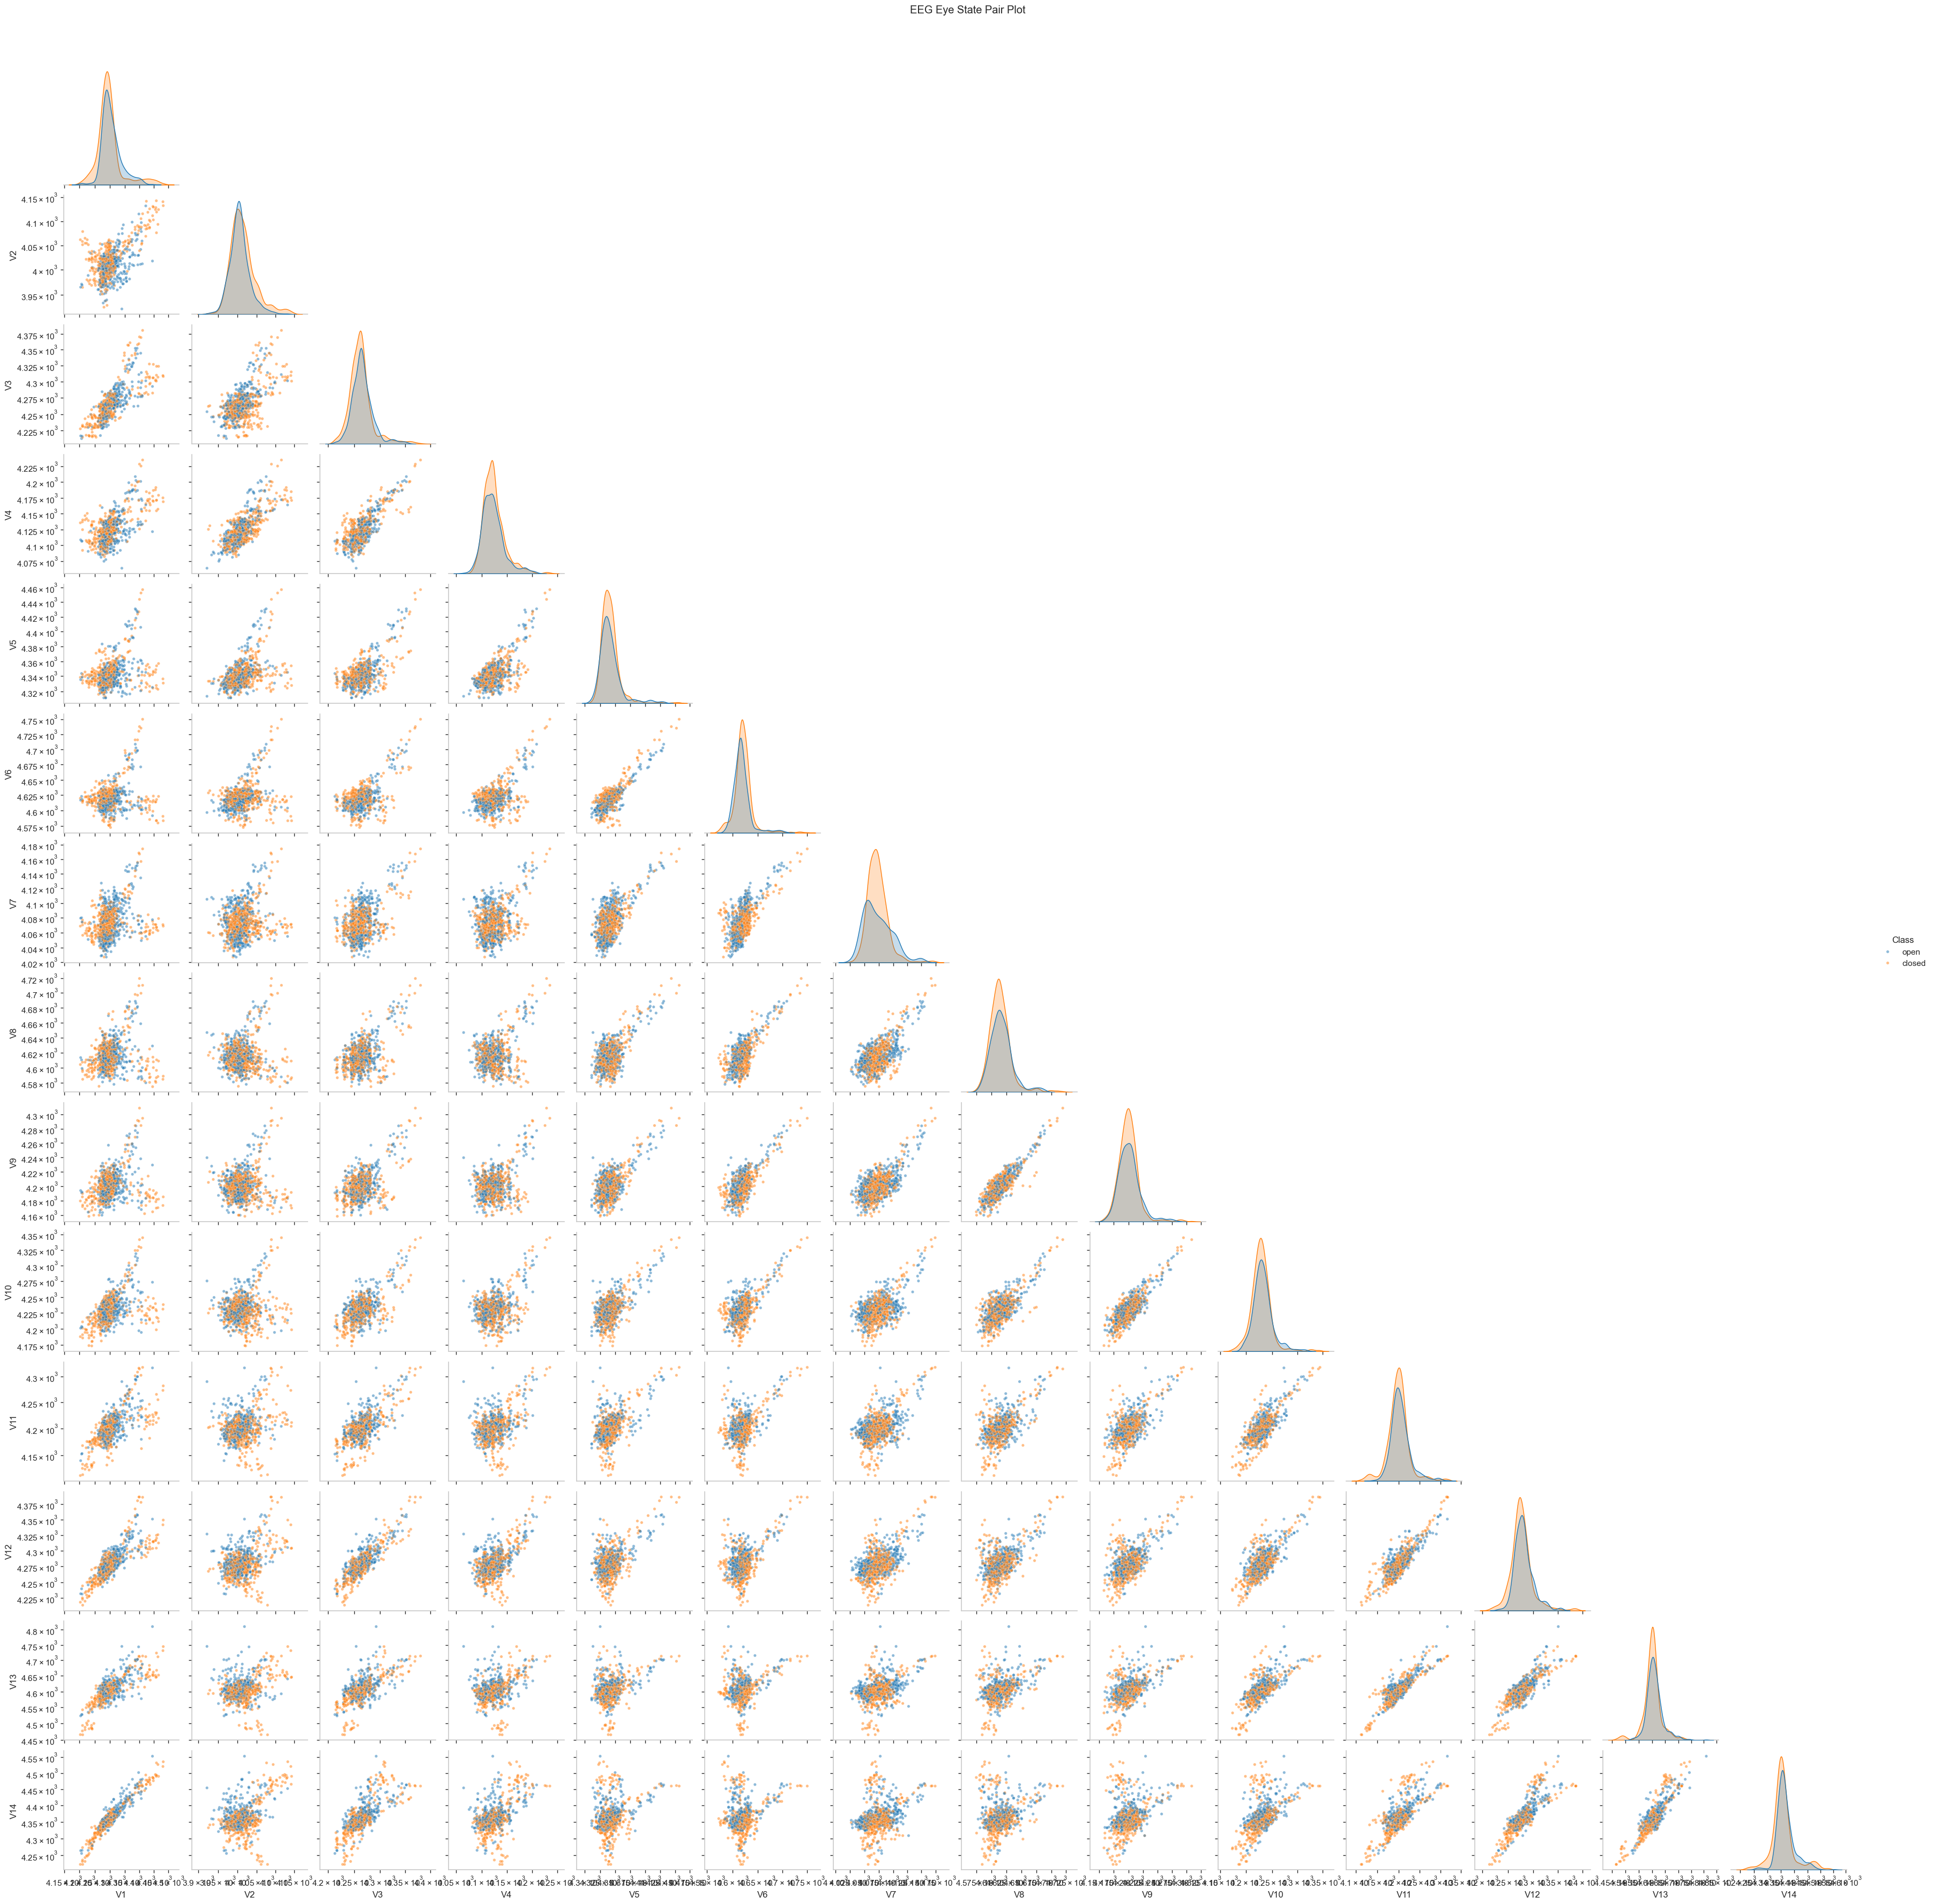

In [4]:
# Pair plot with logarithmic scaling for better visibility
pp = sns.pairplot(
    df.sample(1000, random_state=42),  # Sample for faster plotting
    hue="Class",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 15}
)

for pp in pp.axes.flatten():
    if not pp is None:
        pp.set_xscale("log")
        pp.set_yscale("log")

plt.suptitle("EEG Eye State Pair Plot", y=1.02)
plt.show()

***

Before we can continue with the model selection process, we need to do the final preprocessing steps on our data. Write your own code to split the data into training and test sets, and to standardize the features using a `StandardScaler`. Make sure to fit the scaler only on the training data to avoid data leakage.

Because the features have log-normal distributions, it might be beneficial to apply a log transformation before scaling. You can experiment with this and see if it improves the performance of your models later on.

In [5]:
# Split the data into training and test sets (use stratification!!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Optional: apply log transformation to the features
#X_train = np.log1p(X_train)
#X_test = np.log1p(X_test)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 11984
Test size:  2996


## 2. Baseline classifier (Decision Tree)

We can start with a simple baseline model: a Decision Tree classifier with 5 levels. This will give us a reference point to compare more complex models against.

Similar to the previous exercise session, we will use a helper function to fit the model, compute metrics, and plot the confusion matrix. You can use the `verbose` argument to control whether the function prints the metrics and plots the confusion matrix, or just returns the summary row.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- (optional) add another evaluation metric to the `evaluate_classifier` function (e.g. roc_auc_score) and include it in the summary row.
</div>


In [6]:
from sklearn.metrics import roc_auc_score

def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, class_names=None, title=None, verbose=True):
    """Fit a classifier, print metrics, plot confusion matrix, and return a summary row."""
    # Fit the model
    model.fit(X_tr, y_tr)

    # Make predictions
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # Compute metrics
    acc_tr = accuracy_score(y_tr, pred_tr)
    acc_te = accuracy_score(y_te, pred_te)
    bacc_tr = balanced_accuracy_score(y_tr, pred_tr)
    bacc_te = balanced_accuracy_score(y_te, pred_te)
    roc_auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    roc_auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    if verbose:
        print(title)
        print(f"Train accuracy: {acc_tr:.3f} | Test accuracy: {acc_te:.3f}")
        print(f"Train balanced acc: {bacc_tr:.3f} | Test balanced acc: {bacc_te:.3f}")
        print(f"Train ROC AUC: {roc_auc_tr:.3f} | Test ROC AUC: {roc_auc_te:.3f}")
        print()
        print("Classification report (Test):")
        print(classification_report(y_te, pred_te, target_names=class_names))

        fig, ax = plt.subplots(figsize=(4, 4))
        cm = confusion_matrix(y_te, pred_te)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap="Blues", values_format="d", colorbar=False, ax=ax)
        plt.grid(False)
        plt.title(f"Confusion matrix (Test) — {title}")
        plt.show()

    return {
        "model": title,
        "train_accuracy": acc_tr,
        "test_accuracy": acc_te,
        "train_balanced_accuracy": bacc_tr,
        "test_balanced_accuracy": bacc_te,
        "train_roc_auc": roc_auc_tr,
        "test_roc_auc": roc_auc_te,
    }

Baseline: Decision Tree
Train accuracy: 0.729 | Test accuracy: 0.706
Train balanced acc: 0.719 | Test balanced acc: 0.696
Train ROC AUC: 0.789 | Test ROC AUC: 0.771

Classification report (Test):
              precision    recall  f1-score   support

        open       0.71      0.80      0.75      1651
      closed       0.71      0.59      0.64      1345

    accuracy                           0.71      2996
   macro avg       0.71      0.70      0.70      2996
weighted avg       0.71      0.71      0.70      2996



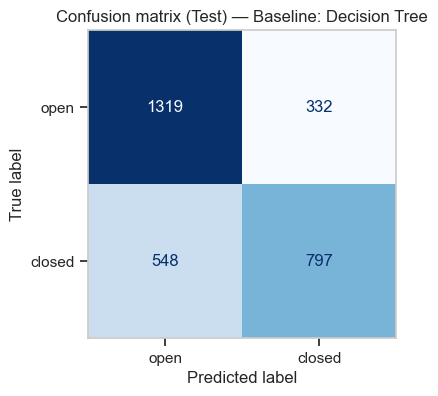

In [7]:
baseline = DecisionTreeClassifier(max_depth=5, random_state=42)

res_baseline = evaluate_classifier(
    baseline,
    X_train, X_test,
    y_train, y_test,
    title="Baseline: Decision Tree",
    class_names=target_names,
 )

## 3. Optimizing one hyperparameter

Now that we have a baseline performance, we can try to improve it by tuning the hyperparameters of the Decision Tree. Because the test set should only be used for the final evaluation, we need to create a validation set from the training data to evaluate the performance for different hyperparameter values. We can do this by using the `train_test_split` function again, or by using cross-validation (CV).

Here we use cross-validation, because it gives a more robust estimate of the model performance by averaging over multiple train/validation splits.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we use stratification for the cross-validation?
- Why should we do cross-validation on the training data (not on the full dataset)?
- With our current setup, there is a risk of data leakage. Can you identify where this happens?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- Stratification ensures that each fold has a similar distribution of the target variable.
- We should do cross-validation on the training data to avoid peeking at the test set. If we use the full dataset for cross-validation, we would be using information from the test set to tune our model, which would lead to an overly optimistic estimate of performance.
- The data leakage happens because we are fitting the scaler on the full training data before doing cross-validation. This means that the validation folds are being transformed using a scaler that has seen the entire training data, which can lead to information from the validation folds leaking into the training process. To avoid this, we should fit the scaler inside the cross-validation loop, so that each fold is scaled independently based only on the training data of that fold.
</div>

In [8]:
# Create the StratifiedKFold object for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
validation_scores = []
for train_idx, val_idx in skf.split(X_train, y_train):
    # Fit the model and evaluate on the training and validation sets
    scores = evaluate_classifier(
        baseline,
        X_train[train_idx, :], X_train[val_idx, :],
        y_train[train_idx], y_train[val_idx],
        verbose=False
    )

    # Append the training and validation scores to the lists
    train_scores.append(scores['train_balanced_accuracy'])
    validation_scores.append(scores['test_balanced_accuracy'])

print(f"CV balanced accuracy (5-fold): mean={np.array(validation_scores).mean():.3f} ± {np.array(validation_scores).std():.3f}")
print(f"Test balanced accuracy (single split): {res_baseline['test_balanced_accuracy']:.3f}")

CV balanced accuracy (5-fold): mean=0.714 ± 0.005
Test balanced accuracy (single split): 0.696


***

Now that we have our cross-validation setup, we can start tuning the hyperparameters of the Decision Tree. A key hyperparameter for decision trees is **max_depth** (how deep the tree is allowed to grow). We will sweep over a range of `max_depth` values and evaluate each setting using cross-validation.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- What happens when `max_depth` is very small (or very large)?
- Why is it better to pick `max_depth` using CV rather than the test set?
- Change the code to also compute the training scores for each `max_depth`. What do you observe? Can you explain the difference between the training and validation scores?
- (optional) Change the scoring metric to `roc_auc_score` and repeat the hyperparameter sweep. How do the results change?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- When `max_depth` is very small, the model is underfitting and will have poor performance on both the training and validation sets. When `max_depth` is very large, the model is overfitting and will have excellent performance on the training set but poor performance on the validation set.
- It is better to pick `max_depth` using CV rather than the test set because the test set should only be used for the final evaluation of the model.
- The training scores are generally higher than the validation scores, especially for larger `max_depth` values. This is a classic sign of overfitting.
</div>

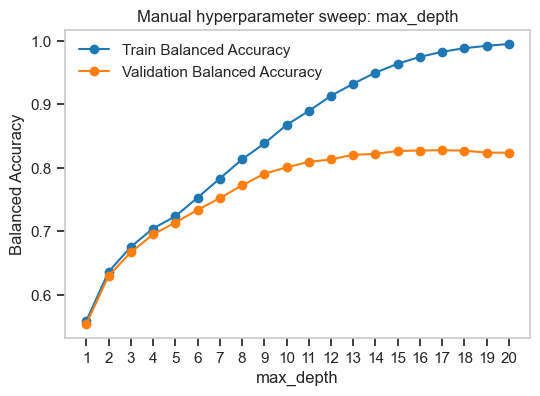

In [9]:
depth_values = list(range(1, 21))

train_mean_scores = []
validation_mean_scores = []

for depth in depth_values:
    # Instantiate the model with the current max_depth
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Cross-validation
    train_scores = []
    validation_scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        scores = evaluate_classifier(
            model,
            X_train[train_idx, :], X_train[val_idx, :],
            y_train[train_idx], y_train[val_idx],
            verbose=False
        )

        train_scores.append(scores['train_balanced_accuracy'])
        validation_scores.append(scores['test_balanced_accuracy'])

    # Store mean and std of scores for this max_depth
    validation_mean_scores.append(np.mean(validation_scores))
    train_mean_scores.append(np.mean(train_scores))

# Plot the results
plt.figure(figsize=(6, 4))
plt.plot(depth_values, train_mean_scores, marker='o', label='Train Balanced Accuracy')
plt.plot(depth_values, validation_mean_scores, marker='o', label='Validation Balanced Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Balanced Accuracy')
plt.title('Manual hyperparameter sweep: max_depth')
plt.xticks(depth_values)
plt.legend()
plt.grid()
plt.show()

Now we will retrain the Decision Tree with the best `max_depth` on the full training set, and evaluate it on the held-out test set.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How does the test performance compare to the CV performance?
- How does the optimized model compare to the baseline model from before?
- How would you summarize the purpose of cross-validation in model selection?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The test performance is slightly lower than the CV performance, with a bigger difference compared to our baseline classifier.
- The optimized model performs much better than the baseline model.
- Cross-validation allows us to estimate the performance of a model on unseen data without using the test set. It helps us to tune hyperparameters and select models in a way that is less prone to overfitting, as it averages performance across multiple train/validation splits.
</div>

Tuned (1 param): Decision Tree (max_depth=17)
Train accuracy: 0.977 | Test accuracy: 0.828
Train balanced acc: 0.976 | Test balanced acc: 0.825
Train ROC AUC: 0.997 | Test ROC AUC: 0.840

Classification report (Test):
              precision    recall  f1-score   support

        open       0.84      0.85      0.84      1651
      closed       0.81      0.80      0.81      1345

    accuracy                           0.83      2996
   macro avg       0.83      0.83      0.83      2996
weighted avg       0.83      0.83      0.83      2996



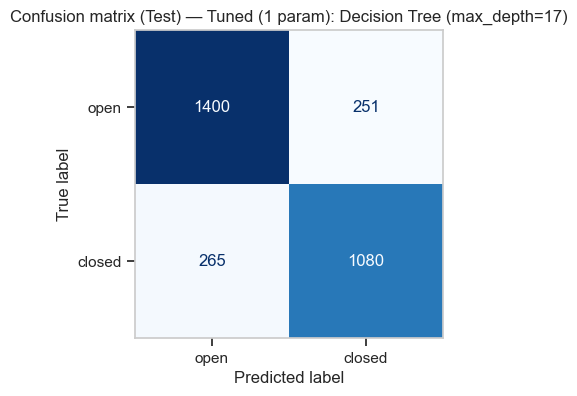

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_roc_auc,test_roc_auc
model,,,,,,
Tuned (1 param): Decision Tree (max_depth=17),0.976969,0.827770,0.975757,0.825472,0.997411,0.840245
Baseline: Decision Tree,0.728972,0.706275,0.718872,0.695737,0.789410,0.771232


In [10]:
best_depth = 17
best_single = DecisionTreeClassifier(max_depth=best_depth, random_state=42)

res_best_single = evaluate_classifier(
    best_single,
    X_train, X_test,
    y_train, y_test,
    title=f"Tuned (1 param): Decision Tree (max_depth={best_depth})",
    class_names=target_names,
 )

pd.DataFrame([res_baseline, res_best_single]).set_index("model").sort_values("test_balanced_accuracy", ascending=False)

## 4. Optimizing multiple hyperparameters (GridSearchCV and RandomizedSearchCV)

In the previous section, we manually tuned one hyperparameter (`max_depth`) by sweeping over a range of values. In practice, we often want to tune multiple hyperparameters at once.

Now we will tune the Decision Tree across multiple hyperparameters simultaneously (maximum depth, minimum number of samples to split, minimum number of samples per leaf, and maximum number of features) using **GridSearchCV** and **RandomizedSearchCV**.

- **Grid search** tries *all* combinations in a fixed grid (can be expensive).
- **Randomized search** samples a fixed number of combinations (often more efficient).

We use **balanced accuracy** as scoring metric again to determine the best hyperparameter combination.

First, let's design the hyperparameter grid and the randomized search space, and then run the searches.

In [11]:
# Define the hyperparameter grid to search
param_grid = {
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"],
}

Now we can use GridsearchCV to automatically scan the hyperparameter grid and find the best combination of values based on the cross-validation performance.

In [12]:
# Set up GridSearchCV
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=skf,
    refit=True, # Automatically refit the best model on the whole training set
    verbose=1
)

# Fit the grid search
grid.fit(X_train, y_train)
print("GridSearch best CV balanced acc:", round(grid.best_score_, 4))
print("GridSearch best params:", grid.best_params_)

Fitting 5 folds for each of 189 candidates, totalling 945 fits
GridSearch best CV balanced acc: 0.8267
GridSearch best params: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


RandomizedSearchCV works similarly, but instead of trying all combinations, it samples a fixed number of combinations from the specified distributions.

In [13]:
rand = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=30,
    scoring="balanced_accuracy",
    cv=skf,
    random_state=42,
    refit=True,
    verbose=1
)

rand.fit(X_train, y_train)
print("RandomizedSearch best CV balanced acc:", round(rand.best_score_, 4))
print("RandomizedSearch best params:", rand.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RandomizedSearch best CV balanced acc: 0.8229
RandomizedSearch best params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}


Now we can use the best models -as found by GridSearchCV and RandomizedSearchCV- to make predictions on the held-out test set and evaluate their performance.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How many hyperparameter combinations were evaluated by GridSearchCV and RandomizedSearchCV?
- Compare the best hyperparameter combinations found by GridSearchCV and RandomizedSearchCV. Are they similar?
- How do the CV performances of the best models from GridSearchCV and RandomizedSearchCV compare?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- GridSearchCV evaluated 189 combinations (3 values for max_depth x 3 values for min_samples_split x 3 values for min_samples_leaf x 7 values for max_features). RandomizedSearchCV evaluated 30 random combinations from the same search space.
- The best hyperparameter combinations are similar, but not identical. This is expected because RandomizedSearchCV only samples a subset of the combinations. <i>(With more iterations, RandomizedSearchCV would likely find a combination closer to the one found by GridSearchCV.)</i>
- The models found by GridSearchCV and RandomizedSearchCV have similar CV performances, although the one found by GridSearchCV is slightly better.
</div>

Selected by GridSearchCV
Train accuracy: 0.950 | Test accuracy: 0.834
Train balanced acc: 0.948 | Test balanced acc: 0.831
Train ROC AUC: 0.989 | Test ROC AUC: 0.847

Classification report (Test):
              precision    recall  f1-score   support

        open       0.84      0.86      0.85      1651
      closed       0.83      0.80      0.81      1345

    accuracy                           0.83      2996
   macro avg       0.83      0.83      0.83      2996
weighted avg       0.83      0.83      0.83      2996



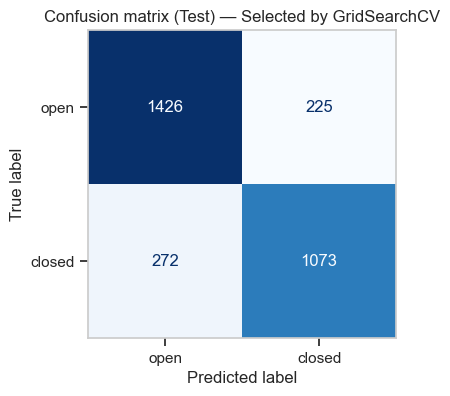

Selected by RandomizedSearchCV
Train accuracy: 0.985 | Test accuracy: 0.833
Train balanced acc: 0.984 | Test balanced acc: 0.831
Train ROC AUC: 0.999 | Test ROC AUC: 0.844

Classification report (Test):
              precision    recall  f1-score   support

        open       0.85      0.85      0.85      1651
      closed       0.82      0.81      0.81      1345

    accuracy                           0.83      2996
   macro avg       0.83      0.83      0.83      2996
weighted avg       0.83      0.83      0.83      2996



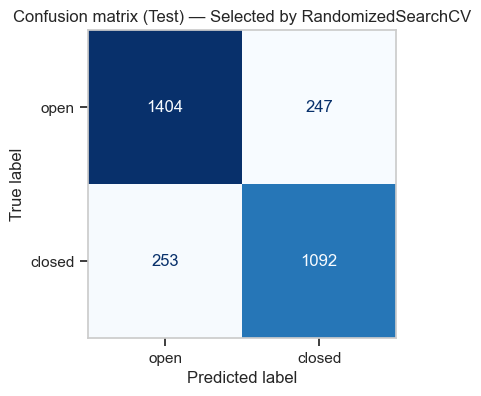

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_roc_auc,test_roc_auc
model,,,,,,
Selected by RandomizedSearchCV,0.985063,0.833111,0.984136,0.831145,0.999289,0.843744
Selected by GridSearchCV,0.950434,0.834112,0.947661,0.830744,0.989384,0.847164
Tuned (1 param): Decision Tree (max_depth=17),0.976969,0.827770,0.975757,0.825472,0.997411,0.840245
Baseline: Decision Tree,0.728972,0.706275,0.718872,0.695737,0.789410,0.771232


In [14]:
# Final evaluation on the held-out test set (once)
res_grid = evaluate_classifier(
    grid.best_estimator_,
    X_train, X_test,
    y_train, y_test,
    title="Selected by GridSearchCV",
    class_names=target_names,
)

res_rand = evaluate_classifier(
    rand.best_estimator_,
    X_train, X_test,
    y_train, y_test,
    title="Selected by RandomizedSearchCV",
    class_names=target_names,
)

pd.DataFrame([res_baseline, res_best_single, res_grid, res_rand]).set_index("model").sort_values("test_balanced_accuracy", ascending=False)

## Wrap-up

In this notebook we have seen a standard model selection workflow for classification:
- Start with a reasonable **baseline**
- Use **cross-validation** on the training set to estimate generalization
- Tune hyperparameters (one-at-a-time or multi-parameter) using CV
- Keep the **test set** for one final evaluation

---

## Optional exercises (for early finishers)


### A. Pipelines to avoid data leakage

In the previous sections, we have been careful to fit the `StandardScaler` only on the training data to avoid data leakage. However, this can be error-prone and cumbersome, especially when we have multiple preprocessing steps and hyperparameter tuning.

Using a Pipeline in scikit-learn allows us to chain together multiple steps (e.g. preprocessing, feature selection, fitting the model, etc.) into a single object. This ensures that all transformations are applied correctly during cross-validation and hyperparameter tuning.

<div class="alert alert-block alert-info">

<b>QUESTIONS</b>

- Are the results the same when using a Pipeline compared to our previous approach? Why or why not?
- How does using a Pipeline help to prevent data leakage?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The results are slightly different, because the feature scaling is now done within our cross-validation loop, which prevents data leakage. In our previous approach, the scaler was fitted on the entire training set before cross-validation, which could lead to an overly optimistic estimate of performance.
- With a Pipeline, all transformations are bundled into a single object that is fitted and transformed during cross-validation. This ensures that the scaling (and any other preprocessing steps) are done independently for each fold, based only on the training data of that fold.
</div>

In [15]:
# Define a pipeline that includes the StandardScaler and the DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid_pipeline = {
    'classifier__max_depth': [None, 3, 5, 7, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': [None, 'sqrt', 'log2'],
}

grid_pipeline = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_pipeline,
    scoring='balanced_accuracy',
    cv=skf,
    refit=True,
    verbose=1
)

grid_pipeline.fit(X_train, y_train)
print("Pipeline GridSearch best CV balanced acc:", round(grid_pipeline.best_score_, 4))
print("Pipeline GridSearch best params:", grid_pipeline.best_params_)

Fitting 5 folds for each of 189 candidates, totalling 945 fits
Pipeline GridSearch best CV balanced acc: 0.8265
Pipeline GridSearch best params: {'classifier__max_depth': 15, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


***

### B. Optimization across multiple classifiers

Model selection is not only about tuning the hyperparameters of a single model, but also about comparing different model families to find the best one for our task. For example, we might want to compare Logistic Regression, Support Vector Machines (SVM), and Random Forests.

Below we provide the code to set up a pipeline and hyperparameter grid for a Decision Tree and Logistic Regression model. You can modify this code to set up pipelines and hyperparameter grids for other classifiers as well.

Suggested models to try:
- SVM (RBF kernel, or other kernels)
- Random Forest
- [Naive Bayes](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB) (Hint: this model does not have hyperparameters to tune, but it can still be included in the comparison)

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which model family gives the best CV balanced accuracy?
- Does the best CV model also perform best on the test set?
- What would change if you used AUC instead of balanced accuracy?
- If you have time, try to include more models (e.g. KNN, Gradient Boosting, etc.) and see how they perform.
- If you would want to investigate the influence of the scaling method, how would you modify the code?
</div>


In [16]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

search_specs = {
    'DecisionTree': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', DecisionTreeClassifier(random_state=42)),
        ]),
        'param_distributions': {
            'clf__max_depth': [None, 3, 5, 7, 10, 15, 20],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
            'clf__max_features': [None, 'sqrt', 'log2'],
        },
     },
    'LogReg': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(solver='saga', max_iter=5000, random_state=42)),
        ]),
        'param_distributions': {
            'clf__l1_ratio': list(np.linspace(0, 1, 50)),
            'clf__C': list(np.logspace(-4, 4, 50))
        },
    },
    # INSERT OTHER MODELS HERE (e.g. SVM, Random Forest, etc.) #
}

results_multi = []
for name, spec in search_specs.items():
    print(f"Searching: {name}")
    rs = RandomizedSearchCV(
        estimator=spec['estimator'],
        param_distributions=spec['param_distributions'],
        n_iter=25,
        scoring='balanced_accuracy',
        cv=skf,
        n_jobs=-1,
        random_state=42,
        refit=True,
        verbose=1
    )
    
    rs.fit(X_train, y_train)
    test_bacc = balanced_accuracy_score(y_test, rs.best_estimator_.predict(X_test))
    results_multi.append({
        'model': name,
        'best_cv_balanced_accuracy': rs.best_score_,
        'test_balanced_accuracy': test_bacc,
        'best_params': rs.best_params_,
    })

pd.DataFrame(results_multi).sort_values('best_cv_balanced_accuracy', ascending=False)

Searching: DecisionTree
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Searching: LogReg
Fitting 5 folds for each of 25 candidates, totalling 125 fits


,model,best_cv_balanced_accuracy,test_balanced_accuracy,best_params
0,DecisionTree,0.822485,0.831819,"{'clf__min_samples_split': 5, 'clf__min_sample..."
1,LogReg,0.584414,0.561761,"{'clf__l1_ratio': 0.1020408163265306, 'clf__C'..."


***

### C. Visualize a 2D loss surface (contour plot) and sampled points

The hyperparameter tuning process can be thought of as an optimization problem, where we are trying to find the hyperparameter values that minimize the loss (or maximize the performance) of our model. Visualizing the loss surface can help us understand the optimization landscape and how different hyperparameter combinations affect the model performance.

We will:
- Train a decision tree classifier
- Perform randomized grid search to sample different hyperparameter combinations
- Plot a contour map and overlay randomly sampled points in the hyperparameter space

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Where is the minimum located?
- Does the loss surface look convex?
- How does the density of sampled points affect your chance of finding a good region?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The minimum is located at max_depth=15, and min_samples_split=2.
- Yes, the loss surface looks convex. It has a single global minimum and no local minima, which makes it easier to optimize.
- With a higher density of sampled points, we have a better chance of finding the optimal region in the hyperparameter space. However, this also increases the computational cost.
</div>


Performing randomized search...
Fitting 5 folds for each of 75 candidates, totalling 375 fits

Best sampled point: max_depth=15, min_samples_split=2
Loss at best point: 0.1733


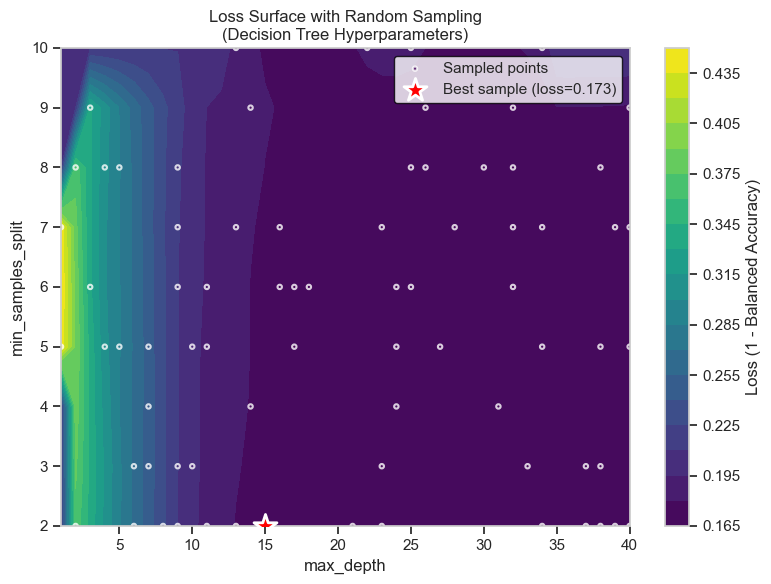

In [17]:
from scipy.interpolate import griddata

# Create a 2D hyperparameter space for max_depth and min_samples_split
# Sample random points and evaluate loss (1 - balanced_accuracy)

# Define parameter ranges
max_depth_range = np.arange(1, 41)
min_samples_split_range = np.arange(2, 11)

# Use RandomizedSearchCV to sample random points
n_random_samples = 75
param_distributions = {
    'max_depth': max_depth_range.tolist(),
    'min_samples_split': min_samples_split_range.tolist(),
}

print("Performing randomized search...")
rand_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=n_random_samples,
    scoring='balanced_accuracy',
    cv=skf,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rand_search.fit(X_train, y_train)

# Extract sampled points and their losses
cv_results = rand_search.cv_results_
random_max_depth = np.array([params['max_depth'] for params in cv_results['params']])
random_min_samples_split = np.array([params['min_samples_split'] for params in cv_results['params']])
random_losses = 1 - cv_results['mean_test_score']

# Find the best sampled point
best_sample_idx = np.argmin(random_losses)
best_max_depth = random_max_depth[best_sample_idx]
best_min_samples_split = random_min_samples_split[best_sample_idx]
best_loss = random_losses[best_sample_idx]

print(f"\nBest sampled point: max_depth={best_max_depth}, min_samples_split={best_min_samples_split}")
print(f"Loss at best point: {best_loss:.4f}")

# Create a grid for visualization (interpolate the loss surface)
grid_max_depth, grid_min_samples_split = np.meshgrid(max_depth_range, min_samples_split_range)
loss_surface = griddata(
    (random_max_depth, random_min_samples_split),
    random_losses,
    (grid_max_depth, grid_min_samples_split),
    method='cubic',
    fill_value=random_losses.mean()
)

# Plot the contour map with sampled points
plt.figure(figsize=(8, 6))
contour = plt.contourf(grid_max_depth, grid_min_samples_split, loss_surface, levels=20, cmap='viridis')
plt.colorbar(contour, label='Loss (1 - Balanced Accuracy)')

# Overlay sampled points
plt.scatter(random_max_depth, random_min_samples_split, c=random_losses, 
            s=10, cmap='viridis', edgecolors='white', linewidth=1.5, 
            label='Sampled points', alpha=0.8)

# Mark the best point
plt.scatter(best_max_depth, best_min_samples_split, c='red', s=300, 
            marker='*', edgecolors='white', linewidth=2, 
            label=f'Best sample (loss={best_loss:.3f})', zorder=5)

plt.xlabel('max_depth')
plt.ylabel('min_samples_split')
plt.title('Loss Surface with Random Sampling\n(Decision Tree Hyperparameters)')
plt.legend(frameon=True, facecolor='white', edgecolor='black')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
